# **HAFEEZ AJIBOLA AREMU**

## *NIGERIA LANGUAGE IDETIFIER - 3MTT CAPESTONE PROJECT*


In this project, i pulled data from AfroFinChain Multilingual and Bible verses. I joined the data together, clean, visualize and analyze it. Using Scikit-Learn, i transformed the raw text into numerical feature matrix and trained a Multinomial Naive bayes probability model to classify input language with more than 99% accuracy.

The Multinomial Naive Bayes classifier achieved an accuracy of 99.77% on the test dataset containing 1,310 samples. The classification report showed very high precision, recall, and F1-scores across English, Hausa, Igbo, and Yoruba. The confusion matrix showed that 1,307 samples were correctly classified, while only 3 Hausa samples were incorrectly classified as English. No misclassification was observed for Igbo or Yoruba samples.

In [6]:
import pandas as pd
import numpy as np
import micropip
await micropip.install("openpyxl")
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

In [7]:
# load AfroFinChain_Multilingual dataset and calling on the first 5 rows

df = pd.read_csv ("AfroFinChain_Multilingual_Web3_QA_EN_YO_PCM_HA_IG.csv")
df.head(5)

,entry_id,term_en,definition_en,category,complexity,en_question,en_answer,ha_question,ha_answer,ig_question,...,ec_en_answer,ec_yo_question,ec_yo_answer,ec_pcm_question,ec_pcm_answer,ec_ha_question,ec_ha_answer,ec_ig_question,ec_ig_answer,ec_source
0,W3AF-001,0x Protocol,An open-source infrastructure that enables the...,Infrastructure,Advanced,Can I use 0x Protocol to swap my coins without...,0x is an open-source infrastructure that enabl...,Zan iya amfani da 0x Protocol don musayar kudi...,Wani tsarin kwamfuta ne wanda ke bawa mutane d...,M̀ nwere ike iji 0x Protocol gbanwere ego m n'...,...,"Yes, you can. 0x Protocol allows you to trade ...",Ṣé mo lè lo 0x Protocol láti ṣe pàṣípàrọ̀ owó ...,"Bẹ́ẹ̀ ni, o lè ṣe é. Ó dàbí bí a ṣe ń ṣe Ajo, ...",I fit use 0x Protocol trade my ETH coins witho...,"Yes, you fit. E be like when you buy recharge ...",Zan iya amfani da 0x Protocol don musayar kudi...,"Kwarai kuwa. Yana kama da tsarin Adashi, inda ...",M̀ nwere ike iji 0x Protocol gbanwere ego m n'...,"Ee, ị nwere ike. Ọ dị ka otu anyị si eme Isusu...",coinmarketcap.com
1,W3AF-002,51% attack,A type of attack where a group gains control o...,Security,Intermediate,Can one group of bad people take over the whol...,A 51% attack occurs when a group gains control...,Shin wasu mugaye za su iya mallakar mafi yawan...,Wani nau'in hari ne inda rukuni ke samun ikon ...,Otu nzukọ ọjọọ nwere ike ịchịkwa ihe karịrị ọk...,...,"Yes, if they control more than half the networ...",Ṣé ẹgbẹ́ kan lè gba ìṣàkóso blockchain láti yí...,"Bẹ́ẹ̀ ni, tí wọ́n bá gba iṣakoso tó ju ìdajì l...",One bad group fit carry more than half of di c...,"Yes, if dem get pass half network power, dem f...",Shin wasu mugaye za su iya mallakar mafi yawan...,"Eh, idan rukuni ya mallaki fiye da rabi, za su...",Otu nzukọ ọjọọ nwere ike ịchịkwa ihe karịrị ọk...,"Ee, ma ọ bụrụ na ha nwere ike ịchịkwa ihe karị...",ethereum.org\n
2,W3AF-003,52-Week High/Low,The highest and lowest market prices of a give...,Analytics,Beginner,How can I know the highest and lowest price a ...,The 52-week high/low represents the highest an...,Ta yaya zan gane mafi girma da mafi kankantar ...,Mafi girma da mafi kankantar farashin jari ne ...,Kedu otu m ga-esi mata ego kacha elu na nke ka...,...,It shows the peak and bottom price for a coin ...,Báwo ni mo ṣe lè mọ iye owó tó ga jù àti èyí t...,Iye owó tó ga jù àti èyí tó kéré jù fún ohun ì...,Wetin be di biggest and smallest price wey dis...,Na di highest and lowest price wey one coin re...,Ta yaya zan gane mafi girma da mafi kankantar ...,Shi ne mafi girma da mafi kankantar farashin j...,Kedu otu m ga-esi mata ego kacha elu na nke ka...,Ọ bụ ọnụahịa kacha elu na nke kacha ala ihe ru...,coinmarketcap.com\n
3,W3AF-004,52-Week Range,The difference between an asset’s highest and ...,Analytics,Beginner,How do I see the lowest and highest price a co...,You check the 52-Week Range; it shows the pric...,Yaya zan iya sanin mafi girma da mafi kankanta...,Za ka duba 52-Week Range; yana nuna mafi girma...,Kedu otu m ga-esi mara ego kacha elu na nke ka...,...,You check the 52-Week Range on any market trac...,Báwo ni mo ṣe lè mọ iye owó tó ga jù àti èyí t...,Wo 52-Week Range; ó ń fi iye owó tó ga jù àti ...,How I go take know di highest and lowest price...,Check 52-Week Range; e show di highest and low...,Yaya zan iya sanin mafi girma da mafi kankanta...,Duba 52-Week Range; yana nuna mafi girma da ma...,Kedu otu m ga-esi mara ego kacha elu na nke ka...,Ị ga-eleba anya na 52-Week Range; ọ bụ ọnụahịa...,coinmarketcap.com
4,W3AF-005,80/20 Rule (Pareto Principle),A principle stating that 20% of actions or par...,Culture,Beginner,Is it true that only a small group of people h...,The Pareto Principle states that 20% of partic...,Shin gaskiya ne wasu mutane kadan ne ke da maf...,Wata ka'ida ce dake cewa kashi 20 na ayyukan m...,Ọ̀ bụ eziokwu na ọ bụ naanị mmadụ ole na ole n...,...,"Yes, this reflects the Pareto Principle where ...",Ṣé òótọ́ ni pé àwọn èèyàn díẹ̀ ló ní iye owó t..

In [8]:
# Bringing out the needed columns from the dataset

df = df[['entry_id','en_question','ha_question','ig_question','yo_question']]
df.head()

,entry_id,en_question,ha_question,ig_question,yo_question
0,W3AF-001,Can I use 0x Protocol to swap my coins without...,Zan iya amfani da 0x Protocol don musayar kudi...,M̀ nwere ike iji 0x Protocol gbanwere ego m n'...,Ṣé mo lè lo 0x Protocol láti ṣe pàṣípàrọ̀ owó ...
1,W3AF-002,Can one group of bad people take over the whol...,Shin wasu mugaye za su iya mallakar mafi yawan...,Otu nzukọ ọjọọ nwere ike ịchịkwa ihe karịrị ọk...,Ṣé ẹgbẹ́ kan lè gba ìṣàkóso blockchain láti yí...
2,W3AF-003,How can I know the highest and lowest price a ...,Ta yaya zan gane mafi girma da mafi kankantar ...,Kedu otu m ga-esi mata ego kacha elu na nke ka...,Báwo ni mo ṣe lè mọ iye owó tó ga jù àti èyí t...
3,W3AF-004,How do I see the lowest and highest price a co...,Yaya zan iya sanin mafi girma da mafi kankanta...,Kedu otu m ga-esi mara ego kacha elu na nke ka...,Báwo ni mo ṣe lè mọ iye owó tó ga jù àti èyí t...
4,W3AF-005,Is it true that only a small group of people h...,Shin gaskiya ne wasu mutane kadan ne ke da maf...,Ọ̀ bụ eziokwu na ọ bụ naanị mmadụ ole na ole n...,Ṣé òótọ́ ni pé àwọn èèyàn díẹ̀ ló ní iye owó t...


In [9]:
# Cheching the summary of our data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1452 entries, 0 to 1451
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   entry_id     1451 non-null   str  
 1   en_question  1451 non-null   str  
 2   ha_question  1451 non-null   str  
 3   ig_question  1451 non-null   str  
 4   yo_question  1451 non-null   str  
dtypes: str(5)
memory usage: 28.4 KB


In [10]:
# Renaming our columns to make it easier to access and call

df.rename(columns={'entry_id':'Entry_id',
                          'en_question':'English',
                          'ha_question':'Hausa',
                          'ig_question':'Igbo',
                          'yo_question':'Yoruba'
                         }, inplace=True)

df.columns

Index(['Entry_id', 'English', 'Hausa', 'Igbo', 'Yoruba'], dtype='str')

In [11]:
# converting our data to standard format for text classification

records = []
for _, row in df.iterrows():
    records.append([row['English'],'English'])
    records.append([row['Hausa'],'Hausa'])
    records.append([row['Igbo'],'Igbo'])
    records.append([row['Yoruba'],'Yoruba'])

language_df= pd.DataFrame(records,columns=['text','language'])
language_df.head()

,text,language
0,Can I use 0x Protocol to swap my coins without...,English
1,Zan iya amfani da 0x Protocol don musayar kudi...,Hausa
2,M̀ nwere ike iji 0x Protocol gbanwere ego m n'...,Igbo
3,Ṣé mo lè lo 0x Protocol láti ṣe pàṣípàrọ̀ owó ...,Yoruba
4,Can one group of bad people take over the whol...,English


In [12]:
# loading our Bible dataset

df2 = pd.read_excel("Bible_verse.xlsx")
df2.head(5)

,verse_id,English,Hausa,Igbo,Yoruba
0,John 1:1,"In the beginning was the Word, and the Word wa...","Tun farar farawa akwai Kalma, Kalman kuwa yana...","1Na mbụ okwu ahụ dịrịị, okwu ahụ na Chineke nọ...","1 Ní àtètèkọ́ṣe ni Ọ̀rọ̀ wà, Ọ̀rọ̀ sì wà pẹ̀l..."
1,John 1:2,This One was in the beginning with God.,Yana nan tare da Allah tun farar farawa.,Ya na Chineke nọ site na mbụ.,Òun ni ó sì wà pẹ̀lú Ọlọ́run ní àtètèkọ́ṣe.
2,John 1:3,"All things came into existence through Him, a...",Ta wurin Kalman ne aka halicci dukan abubuwa....,"E sitere na ya kee ihe niile, ọ dịghịkwa ihe ...",Nípasẹ̀ rẹ̀ ni a dá ohun gbogbo; lẹ́yìn rẹ̀ a...
3,John 1:4,"In Him was life, and the life was the light of...","A cikinsa rai ya kasance, wannan rai kuwa shi...","Nʼime ya ka ndụ dịrịị, ndụ ahụ bụkwa ìhè nye ...","Nínú rẹ̀ ni ìyè wà, ìyè yìí náà sì ni ìmọ́lẹ̀..."
4,John 1:5,"And the light shines in the darkness, and the...","Hasken yana haskakawa cikin duhu, amma duhun ...","ìhè ahụ na-enwu nʼime ọchịchịrị, ma ọchịchịrị...","ìmọ́lẹ̀ náà sì ń mọ́lẹ̀ nínú òkùnkùn, òkùnkùn..."


In [13]:
# Cheching the summary of our data
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   verse_id  189 non-null    str  
 1    English  189 non-null    str  
 2   Hausa     189 non-null    str  
 3   Igbo      189 non-null    str  
 4   Yoruba    189 non-null    str  
dtypes: str(5)
memory usage: 3.8 KB


In [14]:
# Removing unnecessary and extra spaces from our dataset

df2.columns = df2.columns.str.strip()

In [15]:
df2.columns


Index(['verse_id', 'English', 'Hausa', 'Igbo', 'Yoruba'], dtype='str')

In [16]:
 # converting our data to standard format for text classification

records = []
for _, row in df2.iterrows():
    records.append([row['English'],'English'])
    records.append([row['Hausa'],'Hausa'])
    records.append([row['Igbo'],'Igbo'])
    records.append([row['Yoruba'],'Yoruba'])

language_df2 = pd.DataFrame(records,columns=['text','language'])
language_df2.head()

,text,language
0,"In the beginning was the Word, and the Word wa...",English
1,"Tun farar farawa akwai Kalma, Kalman kuwa yana...",Hausa
2,"1Na mbụ okwu ahụ dịrịị, okwu ahụ na Chineke nọ...",Igbo
3,"1 Ní àtètèkọ́ṣe ni Ọ̀rọ̀ wà, Ọ̀rọ̀ sì wà pẹ̀l...",Yoruba
4,This One was in the beginning with God.,English


In [17]:
# The extracted columns from AfroFinChain_Multilingual dataset is being joined with Bible verse dataset and naming it Nigeria_id. i also call on the first 10 rows.
Nigeria_id = pd.concat([language_df,language_df2],ignore_index =True)
Nigeria_id.head(10)

,text,language
0,Can I use 0x Protocol to swap my coins without...,English
1,Zan iya amfani da 0x Protocol don musayar kudi...,Hausa
2,M̀ nwere ike iji 0x Protocol gbanwere ego m n'...,Igbo
3,Ṣé mo lè lo 0x Protocol láti ṣe pàṣípàrọ̀ owó ...,Yoruba
4,Can one group of bad people take over the whol...,English
5,Shin wasu mugaye za su iya mallakar mafi yawan...,Hausa
6,Otu nzukọ ọjọọ nwere ike ịchịkwa ihe karịrị ọk...,Igbo
7,Ṣé ẹgbẹ́ kan lè gba ìṣàkóso blockchain láti yí...,Yoruba
8,How can I know the highest and lowest price a ...,English
9,Ta yaya zan gane mafi girma da mafi kankantar ...,Hausa


# **Exploratory Data Analysis**

In [18]:
# Checking Nigeria_id summary, shape and data type
Nigeria_id.info()
Nigeria_id.shape
Nigeria_id.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 6564 entries, 0 to 6563
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      6560 non-null   str  
 1   language  6564 non-null   str  
dtypes: str(2)
memory usage: 51.4 KB


text        str
language    str
dtype: object

In [19]:
# Getting the sum of null/missing values in the dataset
Nigeria_id.isna().sum()

text        4
language    0
dtype: int64

In [20]:
# Dropping the null/missing values in the dataset
Nigeria_id = Nigeria_id.dropna()
Nigeria_id

,text,language
0,Can I use 0x Protocol to swap my coins without...,English
1,Zan iya amfani da 0x Protocol don musayar kudi...,Hausa
2,M̀ nwere ike iji 0x Protocol gbanwere ego m n'...,Igbo
3,Ṣé mo lè lo 0x Protocol láti ṣe pàṣípàrọ̀ owó ...,Yoruba
4,Can one group of bad people take over the whol...,English
...,...,...
6559,Gbogbo ọdún tí Lamẹki gbé láyé jẹ́ ẹẹdẹgbẹrin...,Yoruba
6560,"Noah was five hundred years old, then Noah be...",English
6561,"Bayan Nuhu ya yi shekara 500, sai ya haifi Sh...",Hausa
6562,Noa we b͕a nnù arọ na ọgu ise: Noa we mua She...,Igbo


In [21]:
# Getting the sum of dulicated data in the dataset
Nigeria_id.duplicated().sum()

np.int64(14)

In [22]:
# Dropping the dulicated data in the dataset
Nigeria_id = Nigeria_id.drop_duplicates()

In [23]:
# Checking the shape of the dataset after dropping the null and duplicates
Nigeria_id.shape

(6546, 2)

In [24]:
# Getting the unique values of Languge column 
Nigeria_id['language'].unique()

<StringArray>
['English', 'Hausa', 'Igbo', 'Yoruba']
Length: 4, dtype: str

language
English    1640
Yoruba     1639
Hausa      1636
Igbo       1631
Name: count, dtype: int64


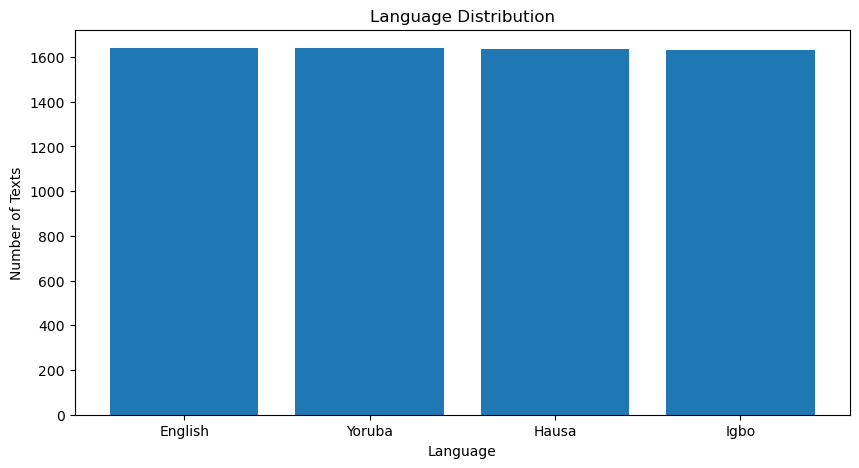


 The bar chart shows that the language are distribute with differences of 1,3 and 5 inbetween the four languages. it also revealed that English has the highest distribution, Yoruba behind it and Igbo with the lowest distribution


In [25]:
# Used value_count to get the count of each language and also to check if they a well distributed to give a balance dataset. i also visualize the result. 
Lang_counts = Nigeria_id['language'].value_counts()
print(Lang_counts)

plt.figure(figsize=(10, 5))
plt.bar(Lang_counts.index,Lang_counts.values)

plt.xlabel('Language')
plt.ylabel('Number of Texts')
plt.title('Language Distribution')

plt.show()

 
print("\n The bar chart shows that the language are distribute with differences of 1,3 and 5 inbetween the four languages. it also revealed that English has the highest distribution, Yoruba behind it and Igbo with the lowest distribution")

In [26]:
# Getting the percentage of each language
Nigeria_language_percentage = (Nigeria_id['language'].value_counts(normalize=True) * 100).round(2)
Nigeria_language_percentage

language
English    25.05
Yoruba     25.04
Hausa      24.99
Igbo       24.92
Name: proportion, dtype: float64

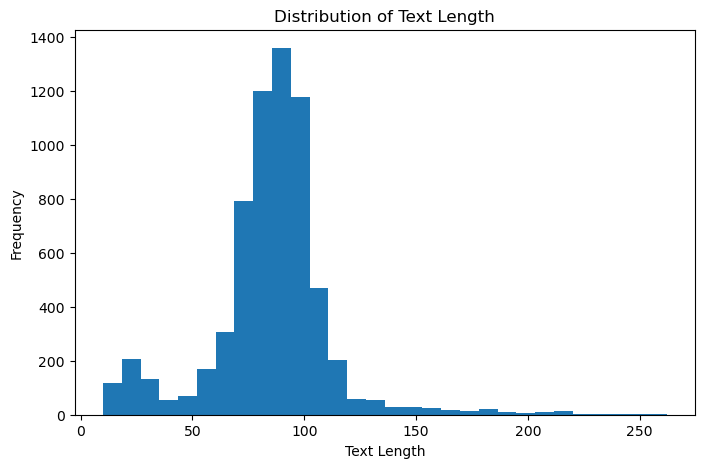


 The histogram  shows that the distribution is right-skewed. it shows that the dataset contains some long text samples , but most observations are concentrated around the middle( 80-95 text lenght) with fewer long texts extending beyond 120 -250+ text length 


In [27]:
# creating a new column that shows the length of each language
Nigeria_id['text_length'] = Nigeria_id['text'].str.len()
Nigeria_id.head()

# Text length distribution
plt.figure(figsize=(8, 5))
plt.hist(Nigeria_id['text_length'], bins=30)

plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Distribution of Text Length')

plt.show()

print("\n The histogram  shows that the distribution is right-skewed. it shows that the dataset contains some long text samples , but most observations are concentrated around the middle( 80-95 text lenght) with fewer long texts extending beyond 120 -250+ text length ")

language
English    89.198171
Hausa      84.353301
Igbo       85.697118
Yoruba     80.580842
Name: text_length, dtype: float64


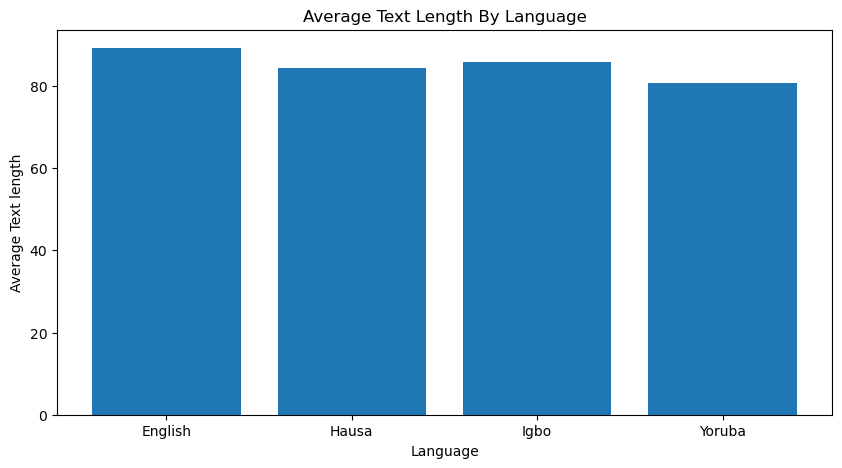

In [28]:
# Finding the average text lengtgh for each language  and also visualizing it.

Avg_length = Nigeria_id.groupby('language')['text_length'].mean()
print(Avg_length)


plt.figure(figsize=(10, 5))
plt.bar(Avg_length.index,Avg_length.values)

plt.xlabel('Language')
plt.ylabel('Average Text length')
plt.title('Average Text Length By Language')

plt.show()

In [29]:
# showing the mean distribution of the text length
Nigeria_id['text_length'].mean()

np.float64(84.95737855178736)

In [30]:
# showing the minimun distribution of the text length
Nigeria_id['text_length'].min()

np.int64(10)

In [31]:
# showing the maximum distribution of the text length
Nigeria_id['text_length'].max()

np.int64(262)

In [32]:
Nigeria_id['text_length'].describe()

count    6546.000000
mean       84.957379
std        26.905622
min        10.000000
25%        76.000000
50%        87.000000
75%        97.000000
max       262.000000
Name: text_length, dtype: float64

In [33]:
# Checking the data type 
Nigeria_id.dtypes

text             str
language         str
text_length    int64
dtype: object

In [34]:
# checking for extra spaces in the text column, stripping them and checking the sum
(Nigeria_id['text'].str.strip() == '').sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
6559    False
6560    False
6561    False
6562    False
6563    False
Name: text, Length: 6546, dtype: bool>

In [35]:
# Getting the first 20 rows of text length less than 20
Nigeria_id[Nigeria_id['text_length'] < 20].head(20)

,text,language,text_length
533,"Menene ""Bags""?",Hausa,14
534,"Gịnị bụ ""Bags""?",Igbo,15
545,"Menene ""Baking""?",Hausa,16
546,"Gịnị bụ ""Baking""?",Igbo,17
560,What is the BIS?,English,16
561,"Menene ""BIS""?",Hausa,13
562,"Gịnị bụ ""BIS""?",Igbo,14
563,Kí ni BIS?,Yoruba,10
564,What is the BSA?,English,16
565,"Menene ""BSA""?",Hausa,13


In [36]:
# splitting and preparing the dataset for trainning and testing

X = Nigeria_id['text']  #input
y = Nigeria_id['language'] #output

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5236
Testing samples: 1310


In [37]:
# Checking the numbers of data for training and testing the model
print(y_train.value_counts())
print(y_test.value_counts())

language
English    1312
Yoruba     1311
Hausa      1308
Igbo       1305
Name: count, dtype: int64
language
English    328
Yoruba     328
Hausa      328
Igbo       326
Name: count, dtype: int64


In [38]:
# converting text into numerical features, to make it easy for the model to learn and understand

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [39]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [40]:
# using Multinomial Naive Bayes to train the model

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [41]:
y_pred = nb_model.predict(X_test_tfidf)

In [42]:
# testing first 10 prediction
print(y_pred[:10])

['English' 'Igbo' 'Yoruba' 'Yoruba' 'Igbo' 'Igbo' 'Yoruba' 'English'
 'English' 'English']


# **Model Evaluation** 

In [43]:
#Checking the accuracy of our model

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9977099236641221


In [44]:
# Getting the classification report of our model

print(classification_report(y_test, y_pred))

print("\n The classification report shows that the Naive Bayes classifier correctly distinguishes most English, Hausa, Igbo, and Yoruba text with 99.77% accuracy of the 1,310 test samples, with only a small number of misclassifications between languages.")

              precision    recall  f1-score   support

     English       0.99      1.00      1.00       328
       Hausa       1.00      0.99      1.00       328
        Igbo       1.00      1.00      1.00       326
      Yoruba       1.00      1.00      1.00       328

    accuracy                           1.00      1310
   macro avg       1.00      1.00      1.00      1310
weighted avg       1.00      1.00      1.00      1310


 The classification report shows that the Naive Bayes classifier correctly distinguishes most English, Hausa, Igbo, and Yoruba text with 99.77% accuracy of the 1,310 test samples, with only a small number of misclassifications between languages.


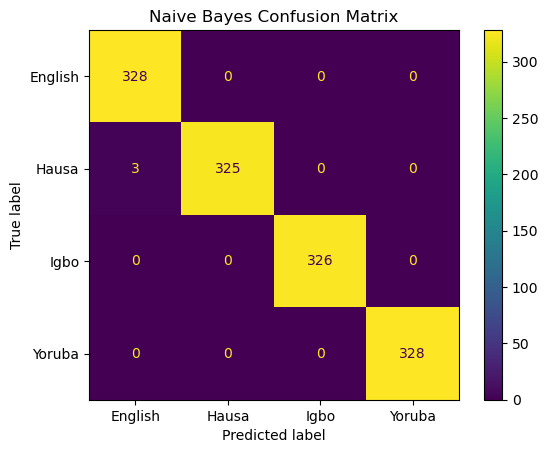


 The confusion matrix showed that 1,307 samples were correctly classified, while only 3 Hausa samples were incorrectly classified as English. No misclassification was observed for Igbo or Yoruba samples.


In [45]:
# plotting the confussion matrix of the model to see if there is any confusion in the model
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_model.classes_
)

disp.plot()

plt.title('Naive Bayes Confusion Matrix')
plt.show()

print("\n The confusion matrix showed that 1,307 samples were correctly classified, while only 3 Hausa samples were incorrectly classified as English. No misclassification was observed for Igbo or Yoruba samples.")

In [48]:
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [46]:
text = input("Enter text: ")

prediction = nb_model.predict(tfidf.transform([text]))[0]

print("Detected Language:", prediction)

Enter text:  ndi


Detected Language: Igbo


In [47]:
joblib.dump(nb_model,"naive_bayes_model.pkl")


['naive_bayes_model.pkl']